<a href="https://colab.research.google.com/github/phanimusunuri1234/Multi-Asset-Market-Risk-Engine/blob/main/Multi_Asset_Market_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── core ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── data fetch ────────────────────────────────────
import yfinance as yf


# ── visualisation ─────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#dates
START_DATE = '2019-01-01'
END_DATE = '2023-01-01'

#equities

EQUTIES = [
    'TCS.NS',        # IT
    'INFY.NS',       # IT
    'HDFCBANK.NS',   # Banking
    'ICICIBANK.NS',  # Banking
    'RELIANCE.NS',   # Energy
    'ONGC.NS',       # Energy
    'HINDUNILVR.NS', # FMCG
    'ITC.NS',        # FMCG
    'SUNPHARMA.NS',  # Pharma
    'DRREDDY.NS'     # Pharma
]

#FX
FX_TICKER = 'USDINR=X'

#Portfolio
PORTFOLIO_VALUE = 10000000

# Bond Parameters
BOND_FACE = 1000000
BOND_COUPON = 0.071
BOND_MATURITY = 10
BOND_YTM = 0.071
BOND_POSITION = 10

W_EQUITY = 0.60
W_FX = 0.20
W_BOND = 0.20

# DATA FETCH

In [ ]:
equity_prices = yf.download(EQUTIES, start=START_DATE, end=END_DATE, auto_adjust=True)['Close'].dropna()
fx_prices = yf.download(FX_TICKER, start=START_DATE, end=END_DATE, auto_adjust = True)['Close'].dropna()

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
equity_prices.head()

Ticker,DRREDDY.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,ONGC.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS
Date,,,,,,,,,,
2019-01-01,498.221832,504.392487,1607.500488,350.957031,553.448425,201.856049,94.748299,498.490570,402.755920,1582.166138
2019-01-02,497.075256,499.790283,1592.773926,351.777130,556.777222,200.356628,93.823151,491.998230,408.794220,1599.212158
2019-01-03,492.545990,495.868988,1596.165771,350.474640,556.860352,199.107086,90.856293,485.928284,405.124786,1579.796143
2019-01-04,496.874573,497.195496,1590.185669,352.356049,550.119629,200.606522,92.961792,488.551941,402.988098,1560.588867
2019-01-07,488.972351,497.946930,1593.086304,354.768097,558.982483,201.106323,94.333572,491.264465,400.201202,1578.091553


In [ ]:
fx_prices.head()

Ticker,USDINR=X
Date,
2019-01-01,69.709999
2019-01-02,69.709999
2019-01-03,69.959999
2019-01-04,70.300003
2019-01-07,69.525002


In [ ]:
# ── MODULE 3: BOND DV01 SETUP ─────────────────────────

def bond_price(face, coupon, ytm, maturity):
    c = face * coupon / 2
    y = ytm / 2
    n = maturity * 2

    pv = sum([c / (1 + y)**t for t in range(1, n+1)])
    pv += face / (1 + y)**n

    return pv

# Base price
P0 = bond_price(BOND_FACE, BOND_COUPON, BOND_YTM, BOND_MATURITY)

# Price after +1 basis point move
P1 = bond_price(BOND_FACE, BOND_COUPON, BOND_YTM + 0.0001, BOND_MATURITY)

# DV01
DV01 = P0 - P1

print("Bond Price:", P0)
print("DV01 per bond:", DV01)
print("Total DV01:", DV01 * BOND_POSITION)

Bond Price: 999999.9999999987
DV01 per bond: 707.0966364138294
Total DV01: 7070.966364138294


In [ ]:
# ── MODULE 4: RETURNS AND YIELD CHANGES ─────────────────────────

# Equity returns
eq_returns = np.log(equity_prices / equity_prices.shift(1)).dropna()

# FX returns
fx_returns = np.log(fx_prices / fx_prices.shift(1)).dropna()
fx_returns = fx_returns.squeeze()

# Bond yield simulation
np.random.seed(42)
n = len(eq_returns)

yield_changes = np.random.normal(0, 0.0003, n)
yield_series = BOND_YTM + np.cumsum(yield_changes)

yield_series = pd.Series(yield_series, index=eq_returns.index)

# Convert to bps
yield_change_bps = yield_series.diff().dropna() * 10000

print(eq_returns.head())
print(fx_returns.head())
print(yield_change_bps.head())

Ticker      DRREDDY.NS  HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS  \
Date                                                                         
2019-01-02   -0.002304    -0.009166      -0.009203      0.002334  0.005997   
2019-01-03   -0.009154    -0.007877       0.002127     -0.003709  0.000149   
2019-01-04    0.008750     0.002672      -0.003754      0.005354 -0.012179   
2019-01-07   -0.016032     0.001510       0.001822      0.006822  0.015982   
2019-01-08    0.004621    -0.008358      -0.007931      0.033299 -0.002459   

Ticker        ITC.NS   ONGC.NS  RELIANCE.NS  SUNPHARMA.NS    TCS.NS  
Date                                                                 
2019-01-02 -0.007456 -0.009812    -0.013110      0.014881  0.010716  
2019-01-03 -0.006256 -0.032133    -0.012414     -0.009017 -0.012215  
2019-01-04  0.007503  0.022910     0.005385     -0.005288 -0.012233  
2019-01-07  0.002488  0.014649     0.005537     -0.006940  0.011153  
2019-01-08  0.009189 -0.002709   

#PnL Engine

In [ ]:
# Align all data
common_idx = eq_returns.index.intersection(fx_returns.index).intersection(yield_change_bps.index)

In [ ]:
common_idx

DatetimeIndex(['2019-01-03', '2019-01-04', '2019-01-07', '2019-01-08',
               '2019-01-09', '2019-01-10', '2019-01-11', '2019-01-14',
               '2019-01-15', '2019-01-16',
               ...
               '2022-12-19', '2022-12-20', '2022-12-21', '2022-12-22',
               '2022-12-23', '2022-12-26', '2022-12-27', '2022-12-28',
               '2022-12-29', '2022-12-30'],
              dtype='datetime64[ns]', name='Date', length=985, freq=None)

In [ ]:
eq_returns = eq_returns.loc[common_idx]
fx_returns = fx_returns.loc[common_idx]
yield_change_bps = yield_change_bps.loc[common_idx]

In [ ]:
#Equity PnL
eq_value = PORTFOLIO_VALUE * W_EQUITY / len(EQUTIES)
eq_value

600000.0

In [ ]:
eq_pnl = eq_returns * eq_value
eq_pnl

Ticker,DRREDDY.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,ONGC.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS
Date,,,,,,,,,,
2019-01-03,-5492.159348,-4726.093217,1276.354138,-2225.683352,89.576593,-3753.671534,-19279.545958,-7448.442177,-5410.059369,-7329.175094
2019-01-04,5249.873159,1602.927156,-2252.146885,3212.289758,-7307.238893,4501.550397,13745.707503,3230.846763,-3172.863474,-7339.551618
2019-01-07,-9619.007662,906.122922,1093.454380,4093.297128,9589.424707,1493.012434,8789.143905,3322.089314,-4163.761048,6691.805970
2019-01-08,2772.302480,-5014.545623,-4758.384379,19979.128595,-1475.678254,5513.470350,-1625.347701,-54.270895,23556.548223,-1376.669166
2019-01-09,7561.639355,3924.366653,4775.348924,3305.326355,5393.168239,12843.048672,-8813.111786,3304.131850,936.734506,-2095.031502
...,...,...,...,...,...,...,...,...,...,...
2022-12-26,-8671.773316,11825.204013,-836.087271,9683.599407,2120.383829,14336.124215,6403.570575,5216.600875,-899.252356,4545.305486
2022-12-27,317.681194,607.320412,-5573.192460,4983.685949,4951.494035,-2605.798650,14680.913435,4888.796614,60.067993,1216.170729
2022-12-28,268.141977,-478.419435,-2236.928247,-1133.548333,-1864.432450,2247.085876,-3741.012793,-58.891874,-3097.553345,-441.858706


In [ ]:
eq_total = eq_pnl.sum(axis=1)
eq_total

,0
Date,
2019-01-03,-54298.899317
2019-01-04,11471.393868
2019-01-07,22195.582050
2019-01-08,37516.553631
2019-01-09,31135.621267
...,...
2022-12-26,43723.675457
2022-12-27,23527.139251
2022-12-28,-10537.417330


In [ ]:
# ── FX PnL ─────────────────────────

fx_value = PORTFOLIO_VALUE * W_FX

fx_total = fx_returns * fx_value
fx_total.name = "FX_PnL"

In [ ]:
# ── Bond PnL ─────────────────────────

bond_pnl = -DV01 * BOND_POSITION * yield_change_bps
bond_pnl.name = "Bond_PnL"

In [ ]:
# ── Total Portfolio ─────────────────────────

portfolio_pnl = eq_total + fx_total + bond_pnl
portfolio_pnl.name = "Portfolio_PnL"

In [ ]:
# ── Summary ─────────────────────────

pnl_df = pd.DataFrame({
    "Equity_PnL": eq_total,
    "FX_PnL": fx_total,
    "Bond_PnL": bond_pnl,
    "Portfolio_PnL": portfolio_pnl
})

print(pnl_df.describe())

          Equity_PnL        FX_PnL      Bond_PnL  Portfolio_PnL
count     985.000000    985.000000    985.000000     985.000000
mean     3663.182575    243.053693   -450.678725    3455.557544
std     70865.880204   8206.901014  20809.729576   73921.133111
min   -687743.545287 -37426.461460 -81727.604341 -692719.874246
25%    -27083.786641  -4431.518696 -13817.896884  -32160.772840
50%      6095.314268    -56.274701   -519.931853    4224.891657
75%     39663.632444   4588.587667  13715.685349   44063.902591
max    551834.242006  52790.686804  68756.677016  557415.634225


In [ ]:
pnl_df

,Equity_PnL,FX_PnL,Bond_PnL,Portfolio_PnL
Date,,,,
2019-01-03,-54298.899317,7159.741398,2932.986669,-44206.171250
2019-01-04,11471.393868,9696.410326,-13739.351602,7428.452592
2019-01-07,22195.582050,-22170.840320,-32307.878659,-32283.136928
2019-01-08,37516.553631,8181.617886,4967.071910,50665.243427
2019-01-09,31135.621267,14842.490690,4966.723642,50944.835599
...,...,...,...,...
2022-12-26,43723.675457,-6545.796502,76.420298,37254.299254
2022-12-27,23527.139251,7221.396683,24572.273264,55320.809198
2022-12-28,-10537.417330,-3061.355059,-31891.436471,-45490.208861


In [ ]:
# ── MODULE 6: VAR AND ES ─────────────────────────

# ---------- FULL SAMPLE ----------

VaR_95_full = np.percentile(portfolio_pnl, 5)
VaR_99_full = np.percentile(portfolio_pnl, 1)

ES_95_full = portfolio_pnl[portfolio_pnl <= VaR_95_full].mean()
ES_99_full = portfolio_pnl[portfolio_pnl <= VaR_99_full].mean()


# ---------- RECENT WINDOW (250 DAYS) ----------

recent_pnl = portfolio_pnl.tail(250)

VaR_95_recent = np.percentile(recent_pnl, 5)
VaR_99_recent = np.percentile(recent_pnl, 1)

ES_95_recent = recent_pnl[recent_pnl <= VaR_95_recent].mean()
ES_99_recent = recent_pnl[recent_pnl <= VaR_99_recent].mean()


# ---------- PRINT RESULTS ----------

print("\n--- FULL SAMPLE ---")
print(f"VaR 95%: ₹{VaR_95_full:,.2f}")
print(f"VaR 99%: ₹{VaR_99_full:,.2f}")
print(f"ES 95%: ₹{ES_95_full:,.2f}")
print(f"ES 99%: ₹{ES_99_full:,.2f}")

print("\n--- RECENT (250 DAYS) ---")
print(f"VaR 95%: ₹{VaR_95_recent:,.2f}")
print(f"VaR 99%: ₹{VaR_99_recent:,.2f}")
print(f"ES 95%: ₹{ES_95_recent:,.2f}")
print(f"ES 99%: ₹{ES_99_recent:,.2f}")


--- FULL SAMPLE ---
VaR 95%: ₹-95,474.25
VaR 99%: ₹-171,355.56
ES 95%: ₹-166,849.49
ES 99%: ₹-338,180.16

--- RECENT (250 DAYS) ---
VaR 95%: ₹-94,250.19
VaR 99%: ₹-138,626.80
ES 95%: ₹-126,966.70
ES 99%: ₹-178,488.59


In [ ]:
#BACKTESTING

In [ ]:
# ── MODULE 7: BACKTESTING ─────────────────────────

window = 250
confidence = 0.99

var_series = []
pnl_series = []

# rolling VaR calculation
for i in range(window, len(portfolio_pnl)):

    sample = portfolio_pnl.iloc[i-window:i]

    var_99 = np.percentile(sample, 1)

    var_series.append(var_99)
    pnl_series.append(portfolio_pnl.iloc[i])

# convert to series
var_series = pd.Series(var_series, index=portfolio_pnl.index[window:])
pnl_series = pd.Series(pnl_series, index=portfolio_pnl.index[window:])

In [ ]:
# breaches: actual loss worse than VaR
breaches = pnl_series < var_series

num_breaches = breaches.sum()
total_obs = len(breaches)

print("Total observations:", total_obs)
print("Number of breaches:", num_breaches)
print("Breach %:", num_breaches / total_obs)

Total observations: 735
Number of breaches: 11
Breach %: 0.014965986394557823


In [ ]:
# breaches: actual loss worse than VaR
breaches = pnl_series < var_series

num_breaches = breaches.sum()
total_obs = len(breaches)

print("Total observations:", total_obs)
print("Number of breaches:", num_breaches)
print("Breach %:", num_breaches / total_obs)

Total observations: 735
Number of breaches: 11
Breach %: 0.014965986394557823


In [ ]:
expected_breaches = (1 - confidence) * total_obs

print("Expected breaches:", expected_breaches)

Expected breaches: 7.350000000000007


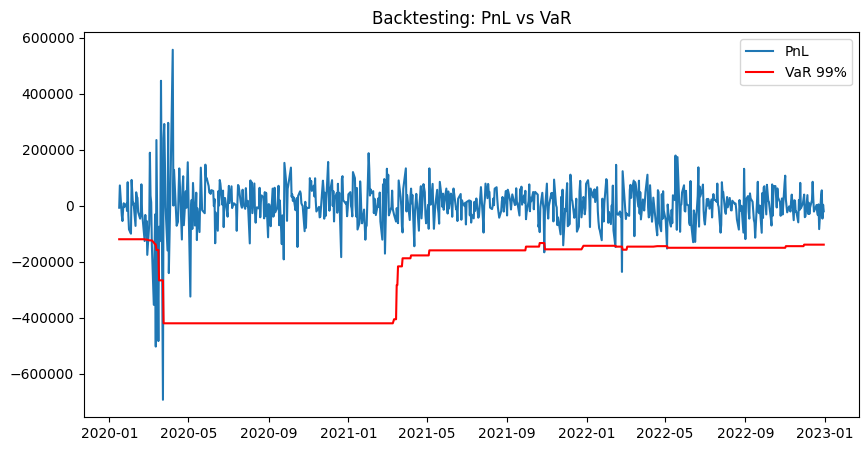

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(pnl_series, label="PnL")
plt.plot(var_series, label="VaR 99%", color='red')
plt.legend()
plt.title("Backtesting: PnL vs VaR")
plt.show()

<Figure size 1000x500 with 0 Axes>

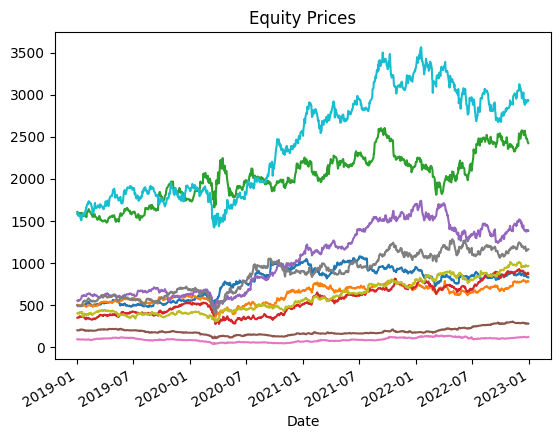

In [ ]:
plt.figure(figsize=(10,5))
equity_prices.plot(legend=False)
plt.title("Equity Prices")
plt.show()

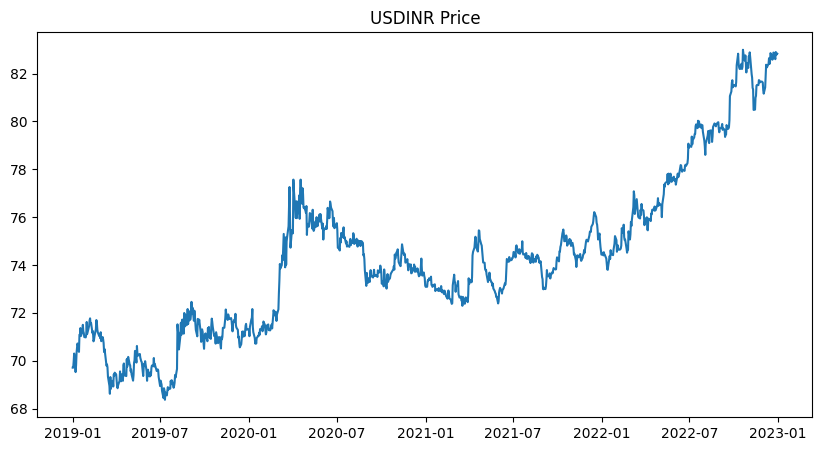

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(fx_prices)
plt.title("USDINR Price")
plt.show()

MODULE 9: PARAMETRIC VAR

In [ ]:
# ── MODULE 9: PARAMETRIC VAR ─────────────────────────

# 1. Bond returns (convert PnL → returns)
bond_value = PORTFOLIO_VALUE * W_BOND
bond_returns = bond_pnl / bond_value
bond_returns.name = "Bond"


# 2. Combine all returns
returns_combined = eq_returns.copy()
returns_combined['FX'] = fx_returns
returns_combined['Bond'] = bond_returns


# 3. Align all data
returns_combined = returns_combined.dropna()


# 4. Define weights
n_eq = len(EQUTIES)
w_equity_each = W_EQUITY / n_eq

weights = np.array(
    [w_equity_each]*n_eq + [W_FX] + [W_BOND]
)


# 5. Mean and covariance
mu = returns_combined.mean().values
cov = returns_combined.cov().values


# 6. Portfolio variance and std
portfolio_variance = weights.T @ cov @ weights
portfolio_std = np.sqrt(portfolio_variance)


# 7. Z-scores
z_95 = 1.645
z_99 = 2.326


# 8. Parametric VaR
VaR_95_param = -z_95 * portfolio_std * PORTFOLIO_VALUE
VaR_99_param = -z_99 * portfolio_std * PORTFOLIO_VALUE


# 9. Print results
print("\n--- PARAMETRIC VAR ---")
print(f"VaR 95%: ₹{VaR_95_param:,.2f}")
print(f"VaR 99%: ₹{VaR_99_param:,.2f}")


--- PARAMETRIC VAR ---
VaR 95%: ₹-121,600.26
VaR 99%: ₹-171,940.56


In [ ]:
# ── MODULE 9B: PARAMETRIC ES ─────────────────────────

from scipy.stats import norm

# PDF values
pdf_95 = norm.pdf(z_95)
pdf_99 = norm.pdf(z_99)

# ES calculations
ES_95_param = - (portfolio_std * pdf_95 / (1 - 0.95)) * PORTFOLIO_VALUE
ES_99_param = - (portfolio_std * pdf_99 / (1 - 0.99)) * PORTFOLIO_VALUE

print("\n--- PARAMETRIC ES ---")
print(f"ES 95%: ₹{ES_95_param:,.2f}")
print(f"ES 99%: ₹{ES_99_param:,.2f}")


--- PARAMETRIC ES ---
ES 95%: ₹-152,441.36
ES 99%: ₹-197,175.15


MODULE 10: MONTE CARLO VAR

In [ ]:
# ── MODULE 10: MONTE CARLO VAR ─────────────────────────

# 1. Use same returns_combined and weights from parametric

cov = returns_combined.cov().values
mu = returns_combined.mean().values

# 2. Cholesky decomposition
L = np.linalg.cholesky(cov)

# 3. Simulation settings
n_assets = len(weights)
n_sim = 10000

# 4. Generate random scenarios
np.random.seed(42)
Z = np.random.normal(size=(n_sim, n_assets))

# Correlated returns
simulated_returns = Z @ L.T + mu

# 5. Portfolio returns
portfolio_returns_sim = simulated_returns @ weights

# 6. Convert to PnL
portfolio_pnl_sim = portfolio_returns_sim * PORTFOLIO_VALUE


# 7. Monte Carlo VaR
VaR_95_mc = np.percentile(portfolio_pnl_sim, 5)
VaR_99_mc = np.percentile(portfolio_pnl_sim, 1)


# 8. Monte Carlo ES
ES_95_mc = portfolio_pnl_sim[portfolio_pnl_sim <= VaR_95_mc].mean()
ES_99_mc = portfolio_pnl_sim[portfolio_pnl_sim <= VaR_99_mc].mean()


# 9. Output
print("\n--- MONTE CARLO RESULTS ---")
print(f"VaR 95%: ₹{VaR_95_mc:,.2f}")
print(f"VaR 99%: ₹{VaR_99_mc:,.2f}")
print(f"ES 95%: ₹{ES_95_mc:,.2f}")
print(f"ES 99%: ₹{ES_99_mc:,.2f}")


--- MONTE CARLO RESULTS ---
VaR 95%: ₹-118,268.37
VaR 99%: ₹-168,488.49
ES 95%: ₹-148,711.59
ES 99%: ₹-190,756.49


Portfolio PnL Time Series

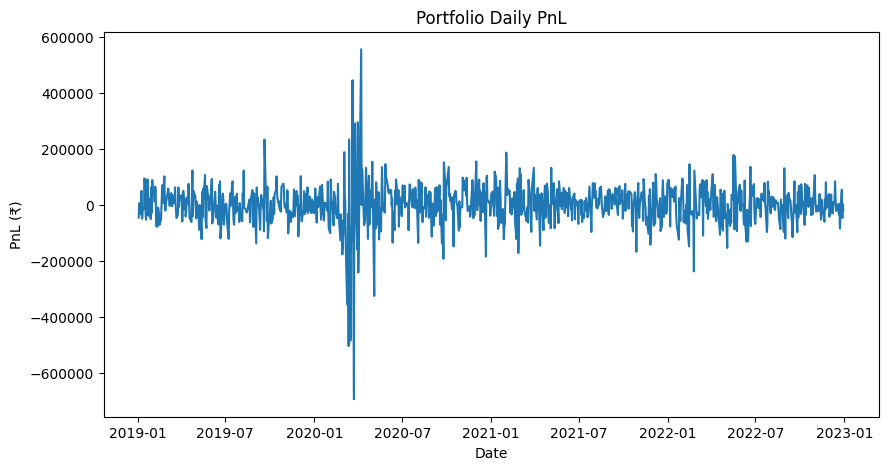

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(portfolio_pnl)
plt.title("Portfolio Daily PnL")
plt.xlabel("Date")
plt.ylabel("PnL (₹)")
plt.show()

VaR Comparison (Bar Chart)

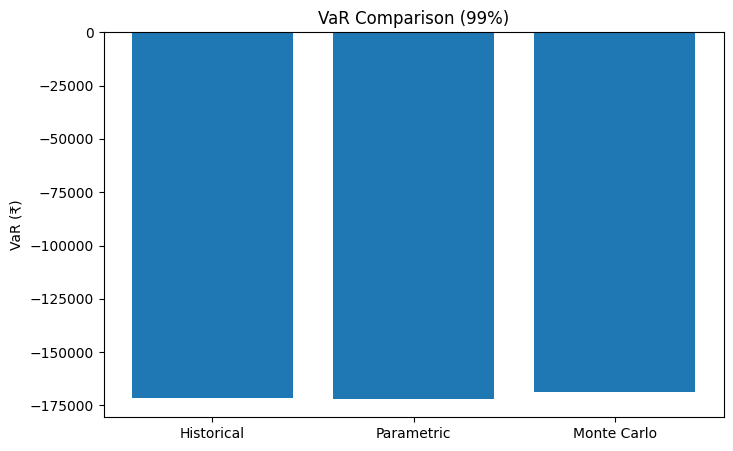

In [ ]:
methods = ['Historical', 'Parametric', 'Monte Carlo']
var_values = [VaR_99_full, VaR_99_param, VaR_99_mc]

plt.figure(figsize=(8,5))
plt.bar(methods, var_values)
plt.title("VaR Comparison (99%)")
plt.ylabel("VaR (₹)")
plt.show()

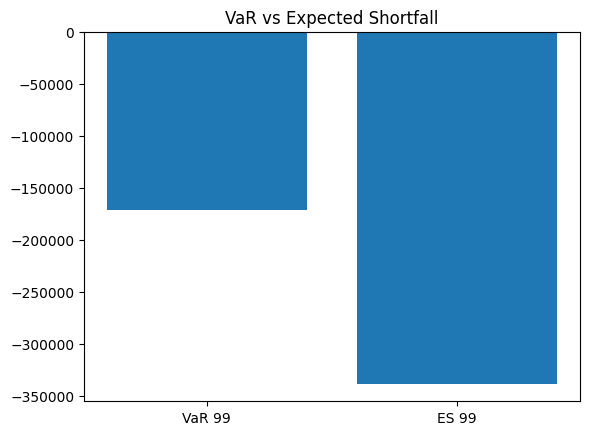

In [ ]:
labels = ['VaR 99', 'ES 99']
values = [VaR_99_full, ES_99_full]

plt.bar(labels, values)
plt.title("VaR vs Expected Shortfall")
plt.show()

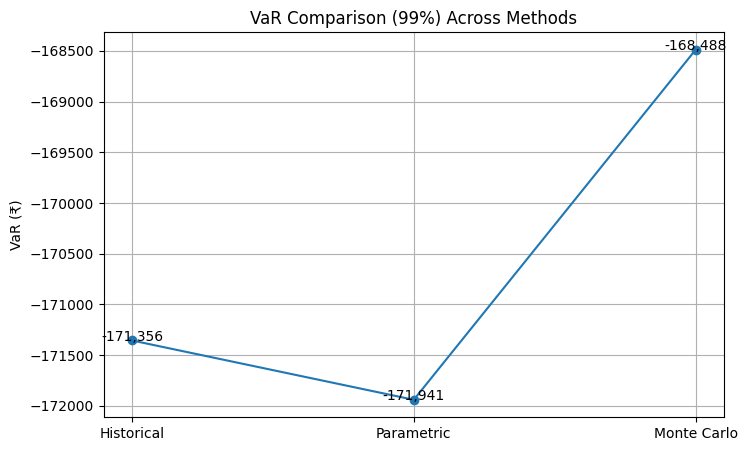

In [ ]:
# ── VAR COMPARISON PLOT ─────────────────────────

methods = ['Historical', 'Parametric', 'Monte Carlo']
var_values = [VaR_99_full, VaR_99_param, VaR_99_mc]

plt.figure(figsize=(8,5))
plt.plot(methods, var_values, marker='o')

for i, v in enumerate(var_values):
    plt.text(i, v, f"{v:,.0f}", ha='center')

plt.title("VaR Comparison (99%) Across Methods")
plt.ylabel("VaR (₹)")
plt.grid()
plt.show()

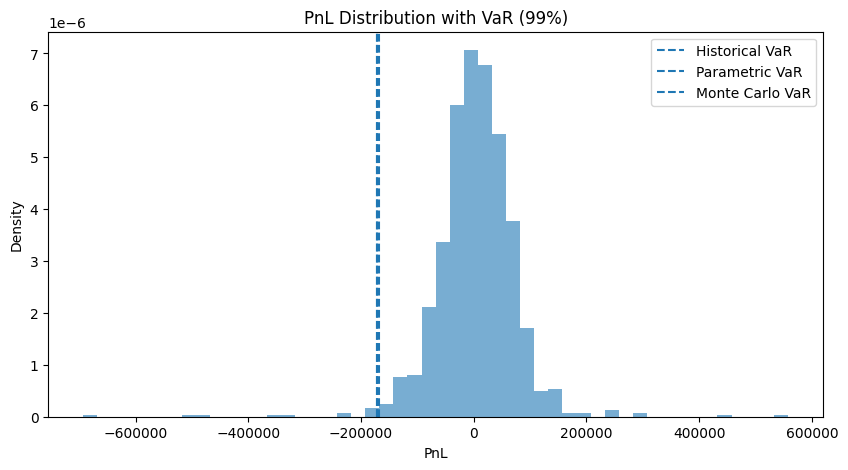

In [ ]:
# ── DISTRIBUTION WITH VAR LINES ─────────────────────────

plt.figure(figsize=(10,5))

plt.hist(portfolio_pnl, bins=50, density=True, alpha=0.6)

plt.axvline(VaR_99_full, linestyle='--', label='Historical VaR')
plt.axvline(VaR_99_param, linestyle='--', label='Parametric VaR')
plt.axvline(VaR_99_mc, linestyle='--', label='Monte Carlo VaR')

plt.title("PnL Distribution with VaR (99%)")
plt.xlabel("PnL")
plt.ylabel("Density")
plt.legend()

plt.show()

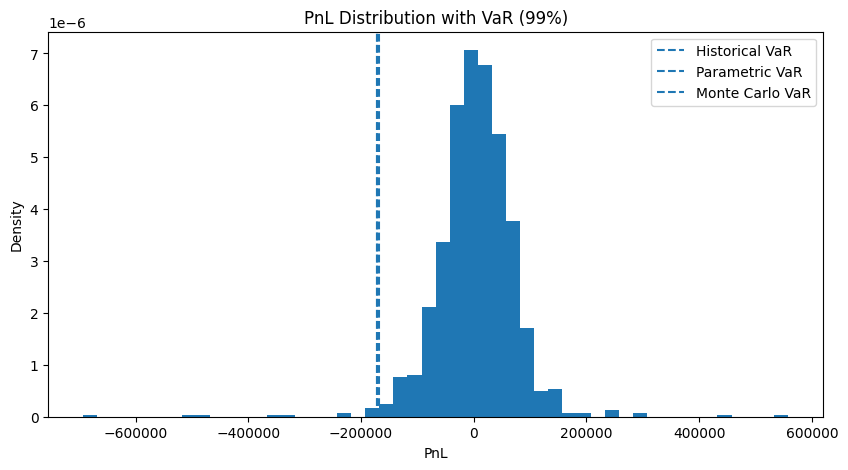

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(portfolio_pnl, bins=50, density=True)

plt.axvline(VaR_99_full, linestyle='--', label='Historical VaR')
plt.axvline(VaR_99_param, linestyle='--', label='Parametric VaR')
plt.axvline(VaR_99_mc, linestyle='--', label='Monte Carlo VaR')

plt.title("PnL Distribution with VaR (99%)")
plt.xlabel("PnL")
plt.ylabel("Density")
plt.legend()

plt.show()

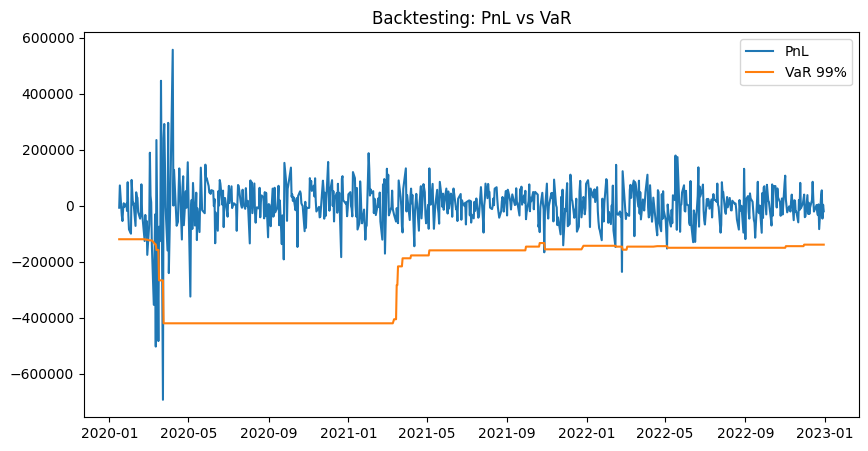

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(pnl_series, label="PnL")
plt.plot(var_series, label="VaR 99%")
plt.legend()
plt.title("Backtesting: PnL vs VaR")
plt.show()

In [ ]:
print(f"Historical VaR 95%: {VaR_95_full:,.0f}")
print(f"Historical VaR 99%: {VaR_99_full:,.0f}")
print(f"Parametric VaR 95%: {VaR_95_param:,.0f}")
print(f"Parametric VaR 99%: {VaR_99_param:,.0f}")
print(f"Monte Carlo VaR 95%: {VaR_95_mc:,.0f}")
print(f"Monte Carlo VaR 99%: {VaR_99_mc:,.0f}")
print(f"ES 95%: {ES_95_full:,.0f}")
print(f"ES 99%: {ES_99_full:,.0f}")

Historical VaR 95%: -95,474
Historical VaR 99%: -171,356
Parametric VaR 95%: -121,600
Parametric VaR 99%: -171,941
Monte Carlo VaR 95%: -118,268
Monte Carlo VaR 99%: -168,488
ES 95%: -166,849
ES 99%: -338,180
